# SCAN Py Example Usage

This notebook demonstrates the public SCAN Py API: simulation helpers, the main detector, result objects, lower-level statistics, bootstrap utilities, ensemble helpers, evaluation metrics, and plotnine visualizations.

Install the package with `pip install scan-py`. Import it as `scan`.

In [1]:
import numpy as np

from scan import (
    adaptive_threshold,
    choose_window_sizes,
    covering_metric,
    ensemble_vote,
    f1_score_cpd,
    ipm_statistic,
    match_change_points,
    merge_change_points,
    plot_change_points,
    plot_swal_curve,
    plot_vote_scree,
    plot_window_votes,
    precision_recall_cpd,
    refine_cusum,
    refine_wasserstein,
    run_one_benchmark,
    scan_cpd,
    scan_single_window,
    simulate_time_series,
    tapered_block_bootstrap,
    wasserstein_statistic,
)

## 1. Simulate Data

`simulate_time_series` returns `(x, cps, means, sigmas)`:

- `x`: simulated observations
- `cps`: true change-points using Python split indexing
- `means`: segment means
- `sigmas`: segment standard deviations

In [2]:
T = 200_000
K = 100
spacing_hint = 298
min_seg_len = 1000
seed = 2000

window_sizes = choose_window_sizes(T, n_windows=7, seed=500)

x, true_cps, means, sigmas = simulate_time_series(
    n=T,
    n_cps=K,
    min_seg_len=min_seg_len,
    change_type="mean",
    seed=seed,
)

x_std = (x - np.mean(x)) / np.std(x)

print(f"Simulating T={T}, K={K}, spacing_hint={spacing_hint}, min_seg_len={min_seg_len}")
print("Window sizes:", window_sizes)
print("True K:", len(true_cps))
print("First true CPs:", true_cps[:10])


Simulating T=200000, K=100, spacing_hint=298, min_seg_len=1000
Window sizes: [134, 225, 241, 294, 323, 325, 394]
True K: 100
First true CPs: [  257  2170  4758  5995  7743  9159 12288 13456 14950 17762]


In [3]:
true_cps

array([   257,   2170,   4758,   5995,   7743,   9159,  12288,  13456,
        14950,  17762,  19461,  21661,  23276,  24893,  26308,  30289,
        32066,  33342,  35245,  36355,  37983,  40071,  41227,  43456,
        45465,  48432,  49769,  51608,  53415,  54440,  55646,  57091,
        58560,  59970,  61164,  62239,  66404,  69041,  71224,  72517,
        77055,  78081,  82268,  84402,  86900,  88961,  91699,  93022,
        94297,  96126,  97430, 100406, 101747, 102813, 103985, 105411,
       107124, 109297, 110483, 111734, 112824, 113949, 116022, 117792,
       118824, 122647, 123654, 125035, 127641, 129700, 130917, 132045,
       134768, 138307, 140237, 141584, 143326, 147196, 150253, 152736,
       154572, 155920, 158503, 161513, 162866, 169928, 173627, 175600,
       177724, 179360, 180921, 183218, 185316, 186801, 188383, 191479,
       192789, 194023, 196760, 198975])

## 2. Run the Main Detector

`scan_cpd` returns a `ScanResult`. Important parameters:

- `window_sizes`: window sizes for the ensemble
- `alpha`: bootstrap tail probability
- `n_boot`: bootstrap replications
- `vote_threshold`: normalized vote cutoff
- `random_state`: reproducibility seed
- `change_type`: `"mean"`, `"var"`, or `"meanvar"`

In [4]:
result = scan_cpd(
    x_std,
    window_sizes=window_sizes,
    n_boot=400,
    alpha=5,
    vote_threshold=0.5,
    random_state=1000,
    change_type="mean",
    batch_size=32,
)

print("Detected K:", len(result.change_points))
print("First detected CPs:", result.change_points[:10])
print("Elapsed seconds:", round(result.metadata["elapsed_seconds"], 4))

Detected K: 100
First detected CPs: [257, 2170, 4758, 5995, 7743, 9159, 12288, 13456, 14950, 17762]
Elapsed seconds: 18.1306


In [6]:
np.array(result.change_points)

array([   257,   2170,   4758,   5995,   7743,   9159,  12288,  13456,
        14950,  17762,  19461,  21661,  23276,  24893,  26308,  30289,
        32066,  33342,  35245,  36355,  37983,  40071,  41227,  43456,
        45465,  48432,  49769,  51608,  53414,  54440,  55646,  57091,
        58560,  59969,  61164,  62239,  66404,  69041,  71224,  72517,
        77055,  78081,  82268,  84402,  86900,  88961,  91699,  93022,
        94297,  96126,  97430, 100406, 101747, 102813, 103985, 105411,
       107124, 109297, 110483, 111734, 112824, 113949, 116022, 117792,
       118824, 122647, 123654, 125035, 127641, 129700, 130917, 132045,
       134768, 138307, 140237, 141584, 143326, 147196, 150253, 152735,
       154572, 155920, 158503, 161513, 162866, 169928, 173627, 175600,
       177723, 179360, 180921, 183218, 185316, 186801, 188383, 191479,
       192789, 194023, 196760, 198975])

## 3. Inspect `ScanResult`

`ScanResult` fields:

- `change_points`: final selected change-points
- `scores`: normalized vote score per candidate
- `votes`: raw vote count per candidate
- `window_results`: per-window diagnostics
- `thresholds`: observed statistics and thresholds
- `parameters`: detector parameters
- `metadata`: runtime and backend metadata
- `segments`: merged voting segments
- `cp_dict`: property with candidates by window size

In [35]:
print("change_points:", result.change_points[:10])
print("scores sample:", list(result.scores.items())[:5])
print("votes sample:", list(result.votes.items())[:5])
print("window_results keys:", sorted(result.window_results.keys()))
print("thresholds keys:", sorted(result.thresholds.keys()))
print("parameters:", result.parameters)
print("metadata:", result.metadata)
print("segments sample:", list(result.segments.items())[:2])
print("cp_dict sample:", {k: v[:5] for k, v in result.cp_dict.items()})

change_points: [2884, 9866, 14603, 15888, 19043, 21277, 23315, 26992, 29159, 31574]
scores sample: [(754, 0.06666666666666667), (1522, 0.13333333333333333), (2250, 0.13333333333333333), (2622, 0.2), (2884, 0.6)]
votes sample: [(754, 1), (1522, 2), (2250, 2), (2622, 3), (2884, 9)]
window_results keys: [122, 133, 152, 208, 222, 237, 240, 260, 289, 318, 320, 336, 383, 387, 427]
thresholds keys: [122, 133, 152, 208, 222, 237, 240, 260, 289, 318, 320, 336, 383, 387, 427]
parameters: {'window_sizes': [122, 133, 152, 208, 222, 237, 240, 260, 289, 318, 320, 336, 383, 387, 427], 'alpha': 1.0, 'n_boot': 400, 'vote_threshold': 0.5, 'min_window': 15, 'max_window': None, 'block_length': None, 'block_length_rule': 'n^(1/3)', 'taper': 'tukey', 'ipm': 'wasserstein', 'change_type': 'mean', 'tolerance': 122, 'random_state': None, 'n_jobs': 8, 'return_all': True, 'eps': 1e-12, 'batch_size': 32}
metadata: {'n_obs': 200000, 'elapsed_seconds': 31.807665100088343, 'index_base': 'python_split_0_based', 'rust_

## 4. Inspect `WindowResult`

Each `WindowResult` contains diagnostics for one window size:

- `window_size`
- `change_points`
- `starts`
- `statistics`
- `lower_thresholds`
- `upper_thresholds`
- `localized_regions`

In [ ]:
first_window = window_sizes[0]
wr = result.window_results[first_window]

print("window_size:", wr.window_size)
print("window change_points:", wr.change_points[:10])
print("scan starts:", wr.starts[:10])
print("observed statistics:", wr.statistics[:5])
print("lower thresholds:", wr.lower_thresholds[:5])
print("upper thresholds:", wr.upper_thresholds[:5])
print("localized regions:", wr.localized_regions[:5])

## 5. Single-Window Scan

Use `scan_single_window` when you want to debug one window size instead of the full ensemble.

In [ ]:
single = scan_single_window(
    x_std,
    window_size=first_window,
    n_boot=100,
    alpha=1,
    random_state=seed,
    change_type="mean",
)

print("single.window_size:", single.window_size)
print("single.change_points[:10]:", single.change_points[:10])
print("len(single.statistics):", len(single.statistics))

## 6. Local Statistics and Localization

These helpers expose lower-level computations:

- `wasserstein_statistic(left, right)`
- `ipm_statistic(left, right, ipm="wasserstein")`
- `localize_cp(x, change_type="meanvar")`
- `refine_cusum(x)`
- `refine_wasserstein(x)`

In [ ]:
left = x_std[:first_window]
right = x_std[first_window : 2 * first_window]
local_block = x_std[true_cps[0] - first_window : true_cps[0] + first_window]

print("wasserstein_statistic:", wasserstein_statistic(left, right))
print("ipm_statistic:", ipm_statistic(left, right))
print("localize_cp mean:", localize_cp(local_block, change_type="mean"))
print("refine_cusum:", refine_cusum(local_block))

split, curve = refine_wasserstein(local_block)
print("refine_wasserstein split:", split)
print("first curve values:", curve[:5])

## 7. Bootstrap Utilities

- `tapered_block_bootstrap` returns bootstrap samples.
- `adaptive_threshold` returns a local bootstrap threshold for a two-window comparison.

In [ ]:
boot = tapered_block_bootstrap(
    x_std[:500],
    sample_length=100,
    block_length=None,
    n_boot=5,
    taper="tukey",
    random_state=123,
)

threshold = adaptive_threshold(
    x_std[:100],
    x_std[100:200],
    alpha=0.05,
    n_boot=100,
    random_state=123,
)

print("bootstrap shape:", boot.shape)
print("adaptive threshold:", threshold)

## 8. Ensemble Helpers

- `merge_change_points` clusters nearby candidates.
- `ensemble_vote` applies voting to a `{window_size: change_points}` mapping.

In [ ]:
clusters = merge_change_points([99, 101, 250, 260], tolerance=10)
selected, scores, votes = ensemble_vote(
    {40: [200, 400], 60: [202, 399], 80: [201]},
    vote_threshold=0.5,
    tolerance=5,
)

print("clusters:", clusters)
print("selected:", selected)
print("scores:", scores)
print("votes:", votes)

## 9. Evaluation Metrics

- `match_change_points`
- `precision_recall_cpd`
- `f1_score_cpd`
- `covering_metric`

In [ ]:
matches = match_change_points(true_cps, result.change_points, tolerance=25)
precision, recall = precision_recall_cpd(true_cps, result.change_points, tolerance=25)
f1 = f1_score_cpd(true_cps, result.change_points, tolerance=25)
covering = covering_metric(true_cps, result.change_points, n=len(x_std))

print("matches sample:", matches[:10])
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print("covering:", covering)

## 10. Benchmark Helper

`run_one_benchmark` simulates data, runs `scan_cpd`, and returns a summary dictionary with the full `ScanResult` under `summary["result"]`.

In [ ]:
small_summary = run_one_benchmark(
    n=2000,
    k=5,
    spacing_hint=300,
    change_type="mean",
    n_boot=50,
    alpha=1,
    vote_threshold=0.5,
    n_jobs=4,
    seed=123,
)

print("summary keys:", sorted(small_summary.keys()))
print("n_detected:", small_summary["n_detected"])
print("detected sample:", small_summary["detected_cps"][:10])

## 11. Plotting

All plotting functions return plotnine `ggplot` objects. Put the plot as the last expression in a notebook cell to display it.

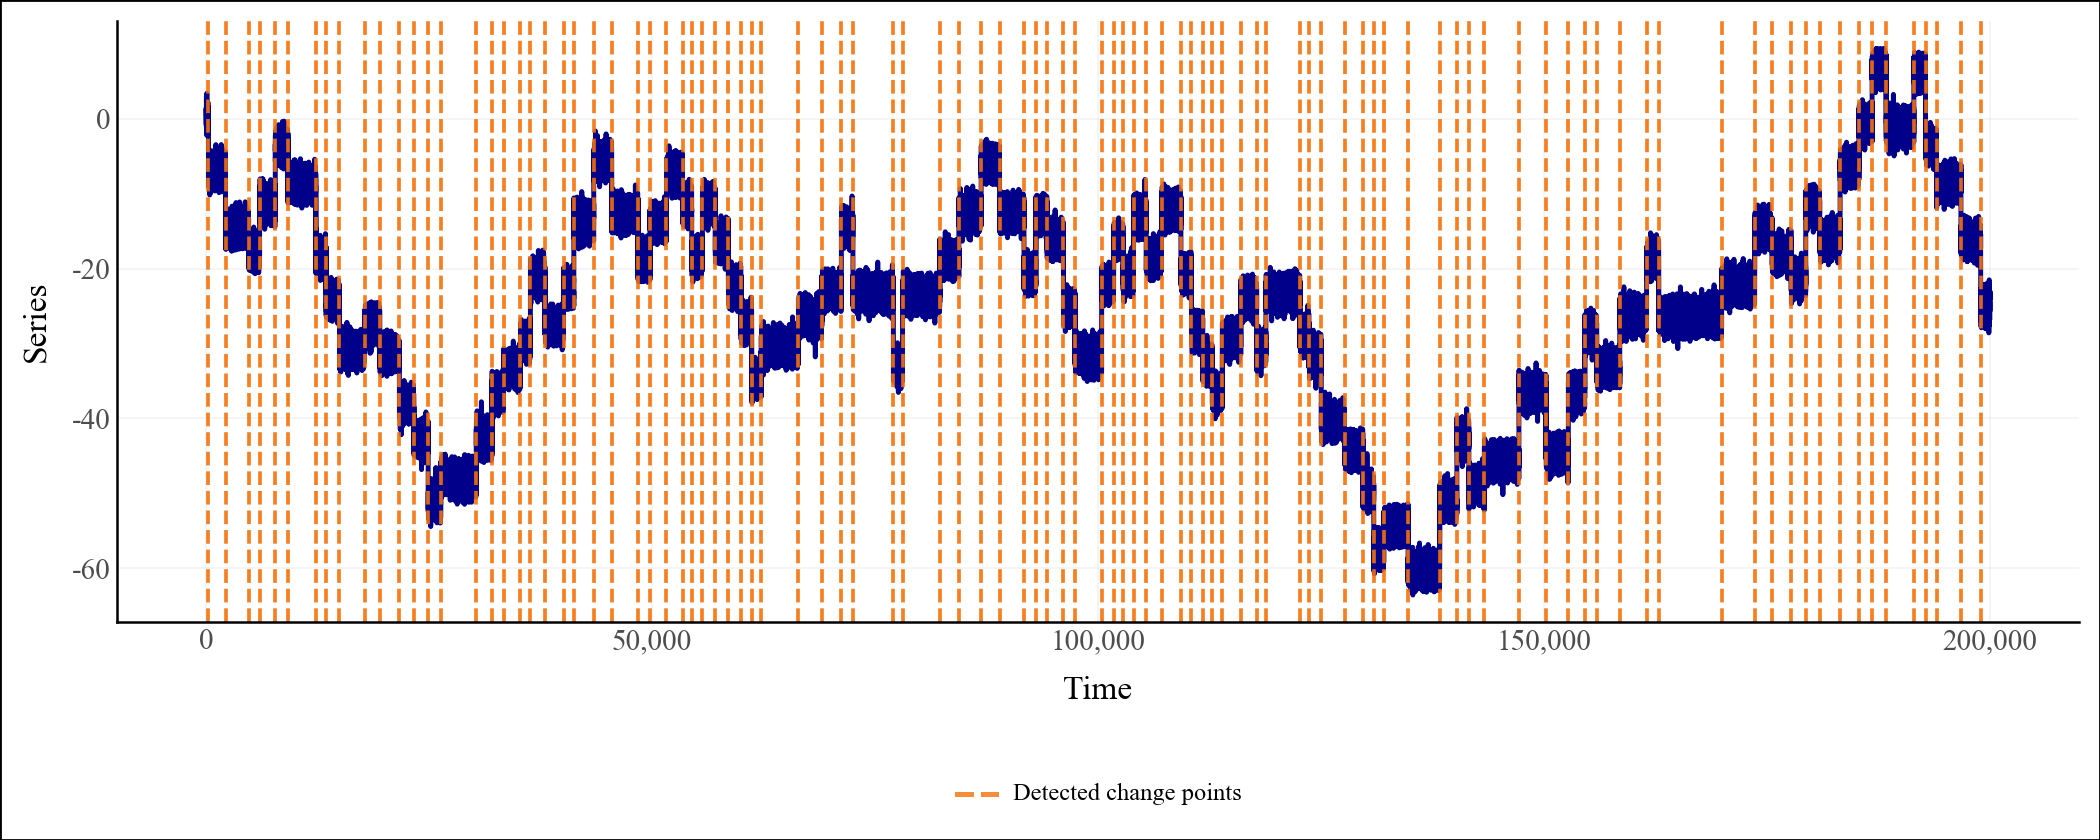

In [5]:
plot_change_points(x, result)

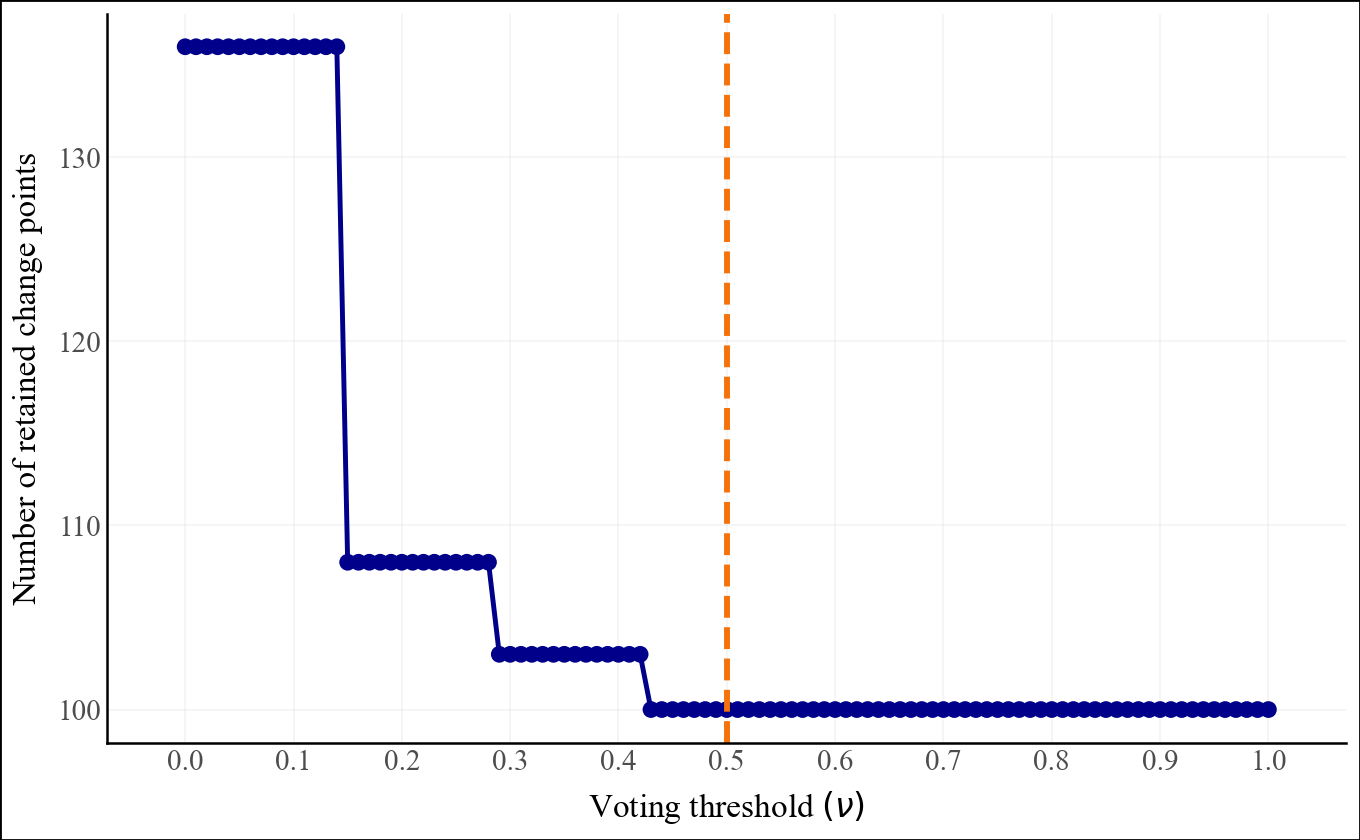

In [6]:
plot_vote_scree(result)

c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\positions\position.py:232: PlotnineWarning: position_stack requires non-overlapping x intervals


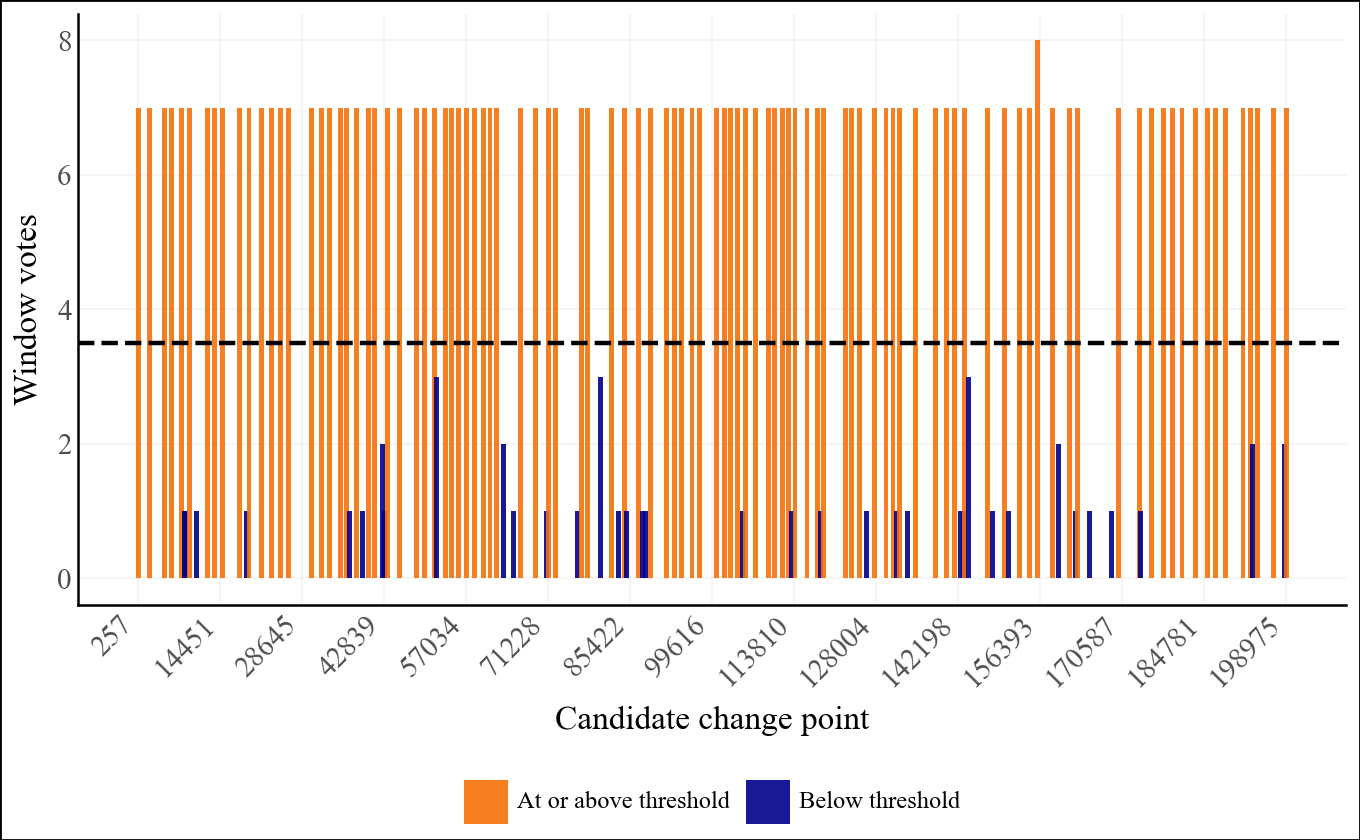

In [7]:
plot_window_votes(result, max_x_labels=15, x_label_angle=45)

In [20]:
plot_thresholds(result, window_size=first_window)

NameError: name 'first_window' is not defined

In [ ]:
if wr.localized_regions:
    start, end = wr.localized_regions[0]
    p = plot_swal_curve(x_std, start, end)
else:
    p = None
p

## 12. Save Plots

Use `.save(...)` in scripts or notebooks when you want files.

In [8]:
from pathlib import Path

out_dir = Path("scan_plots")
out_dir.mkdir(exist_ok=True)

plot_change_points(x_std, result).save(out_dir / "change_points.png", width=11, height=4.8, dpi=600)
plot_vote_scree(result).save(out_dir / "vote_scree.png", width=8, height=4.8, dpi=600)
plot_window_votes(result).save(out_dir / "window_votes.png", width=10, height=4.8, dpi=600)


print("Saved plots to", out_dir.resolve())

c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 11 x 4.8 in image.
c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: scan_plots\change_points.png
c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 4.8 in image.
c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: scan_plots\vote_scree.png
c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 4.8 in image.
c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: scan_plots\window_votes.png
c:\Users\aseelappumud\AppData\Local\anaconda3\Lib\site-packages\plotnine\positions\position.py:232: PlotnineWarning: position_stack requires non-overlapping x intervals


Saved plots to C:\Users\aseelappumud\scan-py\scan-py\scan_plots


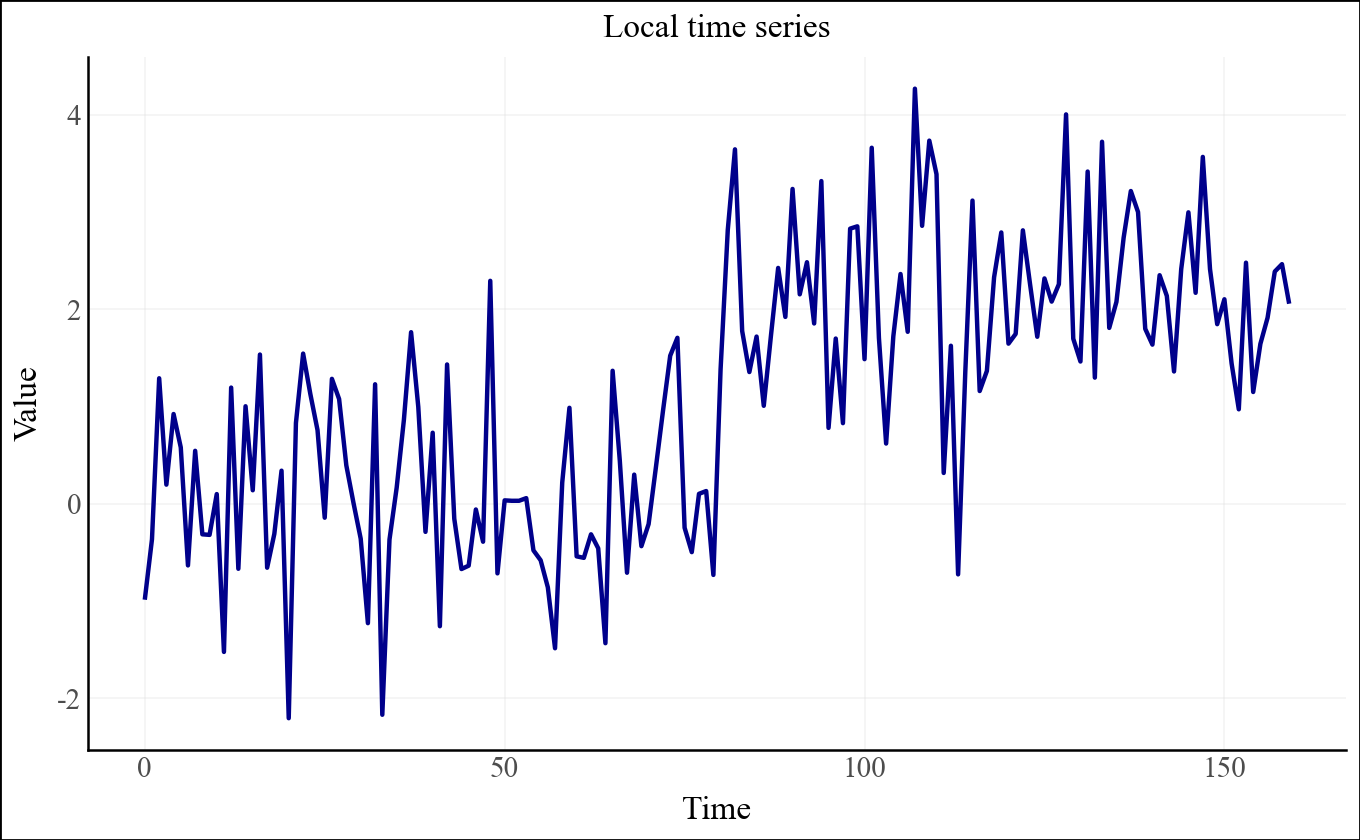

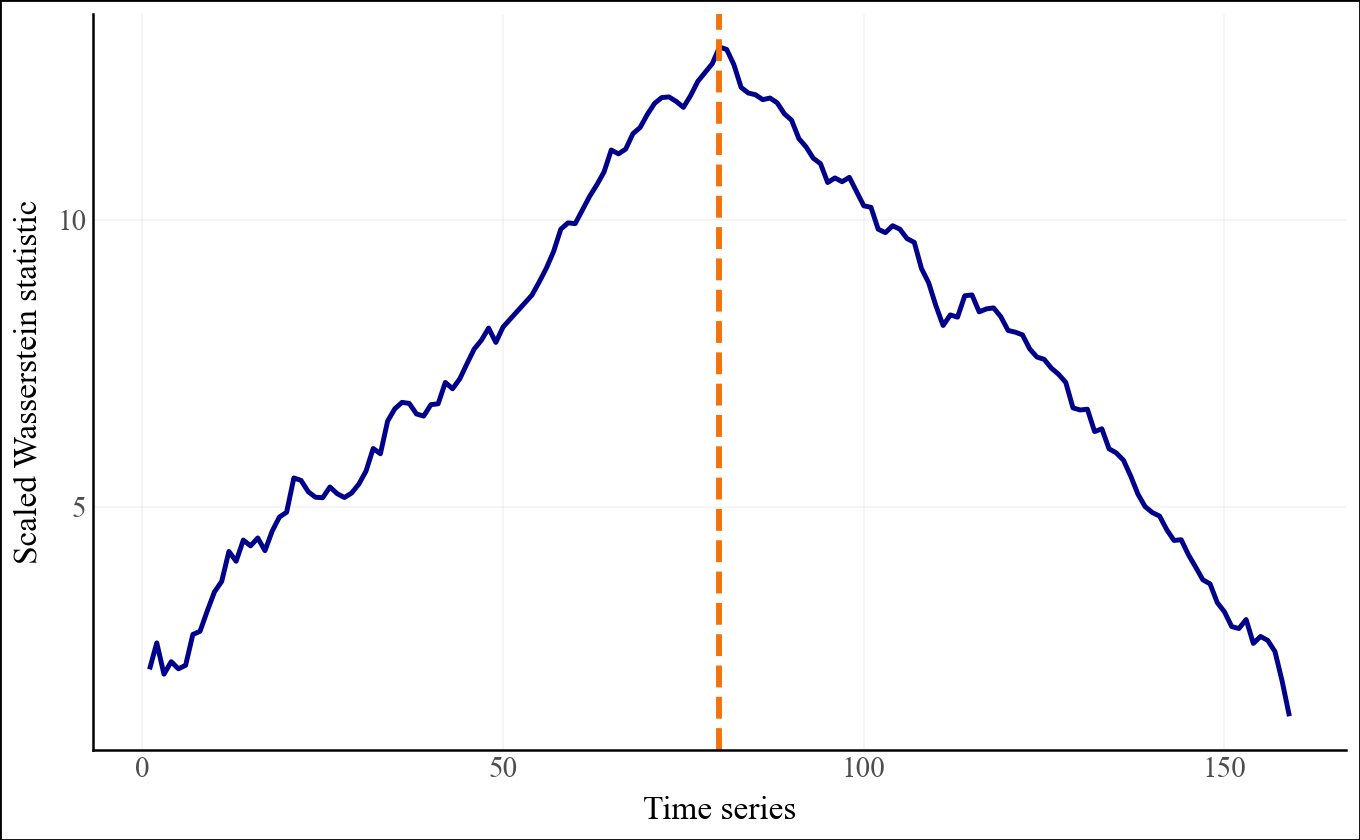

In [3]:
import numpy as np
import matplotlib.pyplot as plt


from scan import swal_statistic, plot_time_series, plot_swal_curve


rng = np.random.default_rng(123)

x_region = np.r_[
    rng.normal(0.0, 1.0, 80),
    rng.normal(2.0, 1.0, 80),
]

local_cp = swal_statistic(x_region, change_type="distribution")

time_series_plot = plot_time_series(
    x_region,
    y_label="Value",
    title="Local time series",
)

swal_curve_plot = plot_swal_curve(
    x_region,
    start=0,
    end=len(x_region),
)




time_series_plot.show(),swal_curve_plot.show()

time_series_plot = plot_time_series(
    x_region,
    y_label="Value",
    title="Local time series",
)

swal_curve_plot = plot_swal_curve(
    x_region,
    start=0,
    end=len(x_region),
)



In [6]:
from pathlib import Path

plots_dir = Path("plots")
time_series_plot.save(
    plots_dir / "local_time_series.png",
    width=6.8,
    height=4.2,
    dpi=300,
    verbose=False,
)

swal_curve_plot.save(
    plots_dir / "swal_curve.png",
    width=6.8,
    height=4.2,
    dpi=300,
    verbose=False,
)

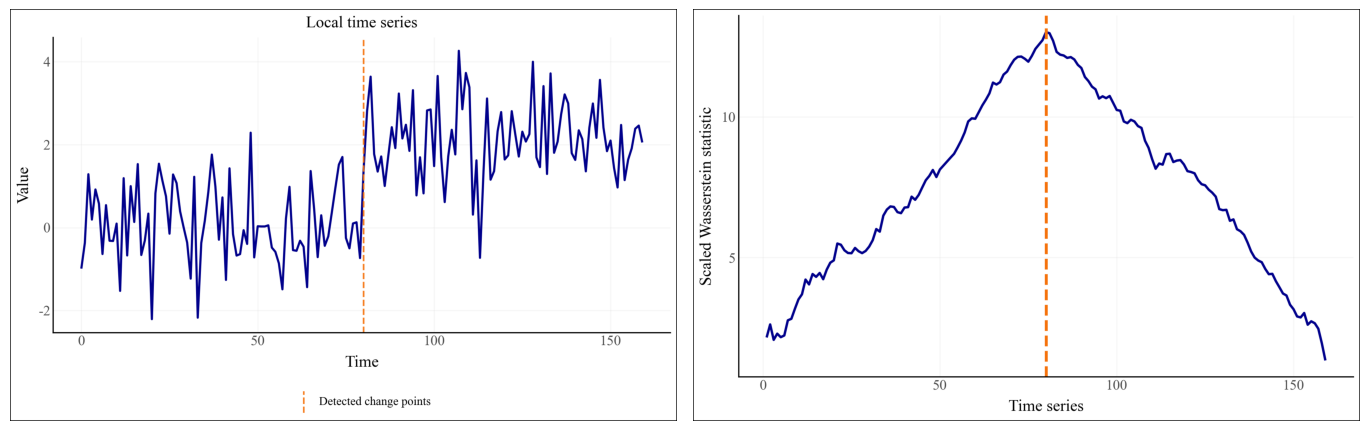

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO

from scan import swal_statistic, plot_time_series, plot_swal_curve


rng = np.random.default_rng(123)

x_region = np.r_[
    rng.normal(0.0, 1.0, 80),
    rng.normal(2.0, 1.0, 80),
]

local_cp = swal_statistic(x_region, change_type="distribution")

time_series_plot = plot_time_series(
    x_region,
    change_points=[local_cp],
    y_label="Value",
    title="Local time series",
)

swal_curve_plot = plot_swal_curve(
    x_region,
    start=0,
    end=len(x_region),
)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.2), constrained_layout=True)

for ax, plot in zip(axes, [time_series_plot, swal_curve_plot]):
    buffer = BytesIO()
    plot.save(buffer, format="png", width=6.8, height=4.2, dpi=300, verbose=False)
    buffer.seek(0)

    image = plt.imread(buffer)
    ax.imshow(image)
    ax.axis("off")

plt.show()

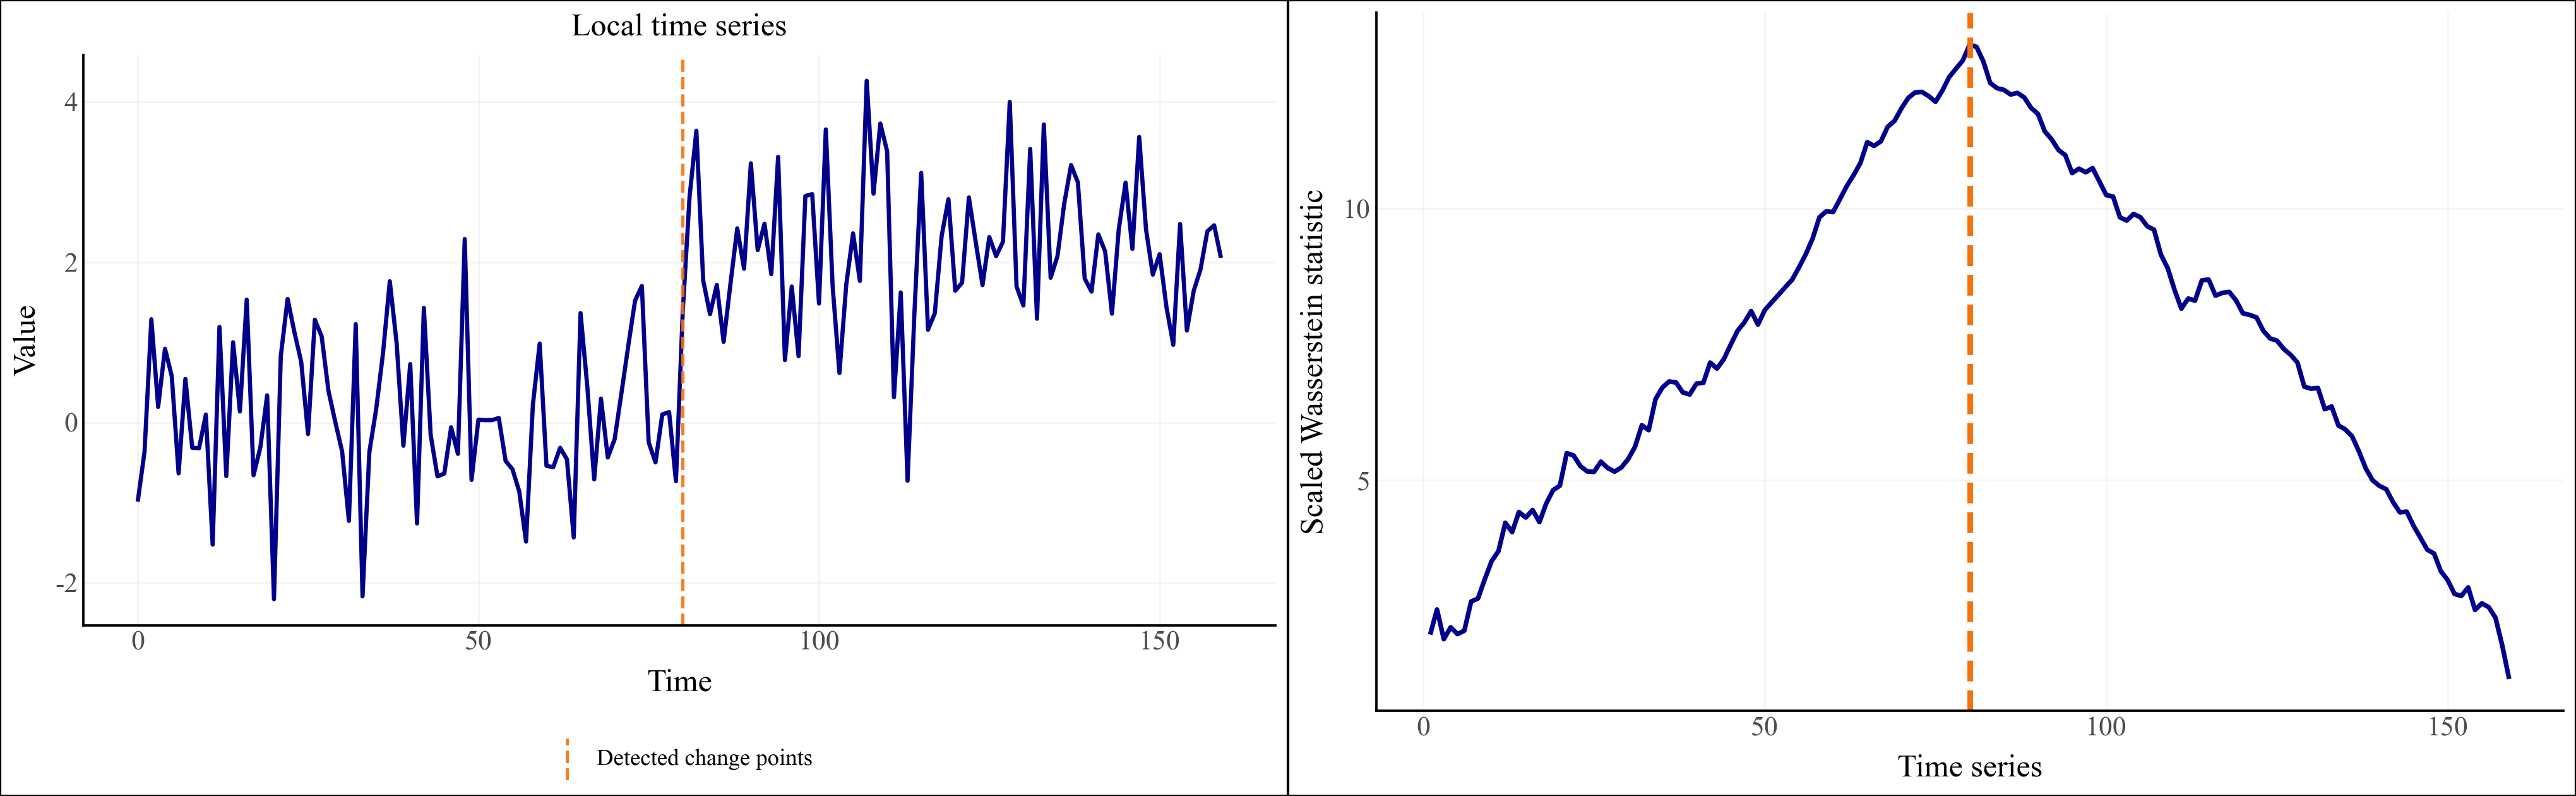

In [7]:
import numpy as np
from scan import swal_statistic, plot_time_series, plot_swal_curve

rng = np.random.default_rng(123)

# Distributional change:
# first segment is standard normal,
# second segment is centered exponential.
x_region = np.r_[
    rng.normal(0.0, 1.0, 100),
    rng.exponential(scale=1.0, size=100) - 1.0,
]

local_cp = swal_statistic(
    x_region,
    change_type="distribution",
)

print(local_cp)

100


In [9]:
time_series_plot = plot_time_series(
    x_region,
    y_label="Value",
    title="Local distributional change",
)

swal_curve_plot = plot_swal_curve(
    x_region,
    start=0,
    end=len(x_region),
)

In [10]:
from pathlib import Path

plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)

time_series_plot.save(
    plots_dir / "distribution_change_time_series.png",
    width=6.8,
    height=4.2,
    dpi=300,
    verbose=False,
)

swal_curve_plot.save(
    plots_dir / "distribution_change_swal_curve.png",
    width=6.8,
    height=4.2,
    dpi=300,
    verbose=False,
)